<a href="https://colab.research.google.com/github/francobarrionuevoenv21/radiometric_uncertainty_sar/blob/main/notebook_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Clone repo from github
!git clone https://github.com/francobarrionuevoenv21/radiometric_uncertainty_sar.git

# Move to the folder containing the .py file
%cd radiometric_uncertainty_sar/radunc

Cloning into 'radiometric_uncertainty_sar'...
remote: Enumerating objects: 76, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 76 (delta 43), reused 31 (delta 19), pack-reused 16 (from 2)
Receiving objects: 100% (76/76), 43.10 MiB | 13.61 MiB/s, done.
Resolving deltas: 100% (43/43), done.
/content/radiometric_uncertainty_sar/radunc


In [2]:
# Import radiometric uncertainty package modules
from radunc import radunc as rdc
from radunc import plot_error_prob as peb
from radunc import get_unct as unct

# Import general libraries
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio as rio
from rasterio.mask import mask

In [3]:
# Define parameters
# Note: .tif images has to be (1, n, m) dimensions. It means the code can process only one band/polarization by time
TIF_PATH = 'https://github.com/francobarrionuevoenv21/radiometric_uncertainty_sar/raw/refs/heads/main/data_test/envisat_wsm_2005_09_12_hh_pot_cal_cg_gk5wgs84_nn_sub_SpkGamma11.tif' # ENVISAT HH image speckle filtered with a Gamma 11x11 window
SAMPLES_PATH = 'https://github.com/francobarrionuevoenv21/radiometric_uncertainty_sar/raw/refs/heads/main/data_test/muestras_merged4326.geojson' # Homogeneus samples vector
SAMPLES_COL = 'nombre' # Samples column name
LIST_CI = [95, 99] # List of confidence intervals to evaluate radiometric uncertainty

### Visualize samples

In [4]:
# Open and read image and vector with samples
scene_test = rio.open(TIF_PATH)
gpd_samples = gpd.read_file(SAMPLES_PATH)

# Reproject vector
gpd_samples_rep = gpd_samples.to_crs(scene_test.crs)

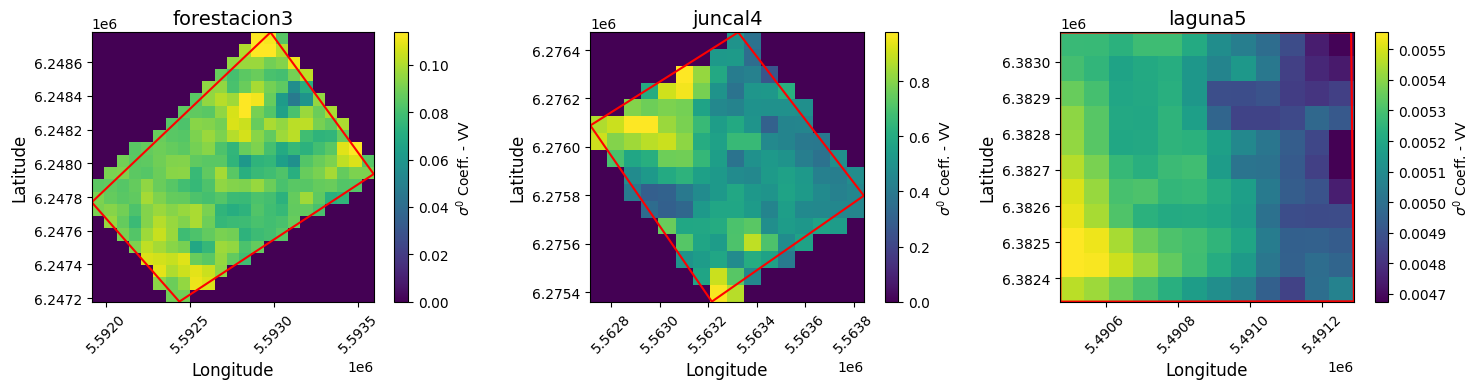

In [5]:
# Plot samples
fig, ax = plt.subplots(1, 3, figsize=(15, 4), tight_layout=True)

for idx, row in gpd_samples_rep.iterrows():
    minx, miny, maxx, maxy = row.geometry.bounds
    plot_extent = (minx, maxx, miny, maxy)

    scene_mask, mask_transform = mask(dataset=scene_test, shapes = [row.geometry], all_touched = True, crop = True)

    im = ax[idx].imshow(scene_mask[0], cmap='viridis',
                   vmin = np.nanpercentile(scene_mask[0], 1), vmax = np.nanpercentile(scene_mask[0], 99),
                   extent = plot_extent)
    fig.colorbar(im, ax=ax[idx], label=r'${\sigma}^{0}$ Coeff. - VV')

    gpd.GeoSeries([row.geometry]).plot(ax=ax[idx], edgecolor='red', linewidth=1.5, facecolor='none')

    ax[idx].set_title(row[SAMPLES_COL], fontsize=14)
    ax[idx].set_ylabel('Latitude', fontsize=12)
    ax[idx].set_xlabel('Longitude', fontsize=12)
    ax[idx].tick_params(axis='x', labelrotation=45)

plt.show()



## Compute Radiometric Uncertainty for each sample from the filtered image

In [6]:
# Run rdc
rdc(TIF_PATH, SAMPLES_PATH, SAMPLES_COL, LIST_CI)

/content/radiometric_uncertainty_sar/radunc/radunc.py:115: UserWarning: CRS mismatch: samples CRS (EPSG:4326) does not match raster CRS (PROJCS["unnamed",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",-90],PARAMETER["central_meridian",-60],PARAMETER["scale_factor",1],PARAMETER["false_easting",5500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]). Reprojecting samples to match raster.
  gdf_samples = read_check_vector(tif_path, samples_path)



Summary table was correctly exported as: output.xlsx ✅


,Sample,Mean,Std,ENL,Rad. Unc. 95 [dB],True CI 95 [%],Rad. Unc. 99 [dB],True CI 99 [%]
0,forestacion3,0.088746,0.011654,57.984505,1.13,95.09,1.49,98.99
1,juncal4,0.576780,0.166235,12.038620,2.54,95.02,3.47,99.00
2,laguna5,0.005137,0.000215,573.285950,0.36,95.27,0.47,99.03


## Complementary functionalities

In [7]:
# Define ENL for testing
ENL = 10

**Compute radiometric uncertainty for an specific ENL**

In [9]:
ci = 99 # Define confidence interval as probability
unct_db, ci_real = unct(ENL, ci)

print(f'Radiometric Uncertainty [dB]: {unct_db:.2f}')
print(f'Real Confidence Interval [%]: {ci_real*100:.2f}')

Radiometric Uncertainty [dB]: 3.86
Real Confidence Interval [%]: 98.99


**Confidence Interval vs Radiometric Uncertainty for an specific ENL**

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Confidence Interval vs Radiometric Uncertainty - ENL:10'}, xlabel='Radiometric Uncertainty (dB)', ylabel='Confidence Interval (%)'>)

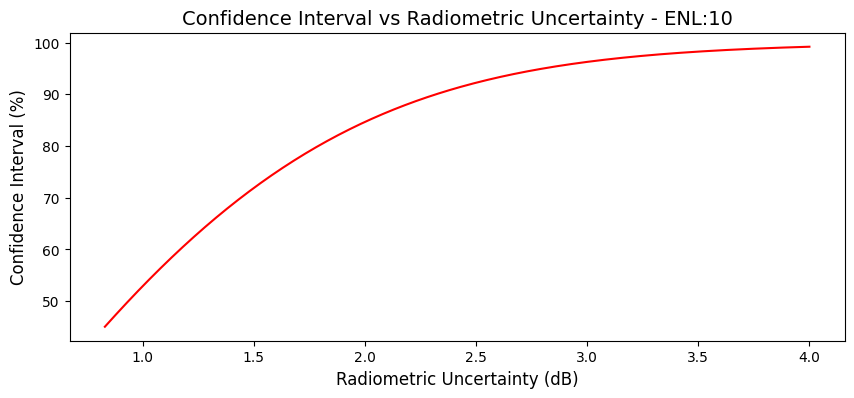

In [10]:
# Run plot
peb(ENL)